In [1]:
import numpy as np
import scipy
import seaborn as sns
from scipy.stats import norm
from collections import defaultdict
from matplotlib import pyplot as plt
from tqdm import tqdm
from pathlib import Path
import torch
from torch.utils.data import DataLoader

import sys
sys.path.append('../../src')
root = Path('../../src')
from utils.yaml import parse_yaml
from utils.utils import load_checkpoint
from metrics.testing import infonce
device = torch.device('cuda:0')

sns.set_context('paper', font_scale=1.3)

In [2]:
DATASET = 'riab'
CRITICS = ['nce'] #['nce', 'nds']

# hyperparams
DATASIZE = 17000
TESTSIZE = 1000
NTEST = 500
NPERM = 200
NBOOT = 1000
ALPHA = 0.05

power = dict()
power['asymp'] = defaultdict(dict)
power['empir'] = defaultdict(dict)
power['perm'] = defaultdict(dict)

## Load model and dataset

In [3]:
# dataset
dataset_cfg = dict()
dataset_cfg['riab'] = root/"config/dataset/riab/riab.present.5000.yml"
dataset_cfg['sinusoid'] = root/"config/dataset/sinusoid/sinusoid-generator.yml"
dataset_cfg['hdgm4'] = root/"config/dataset/hdgm/hdgm4-generator.yml"

# model architectures
model_cfg = defaultdict(dict)
model_cfg['riab']['nce'] = root/"config/model/infonce/id-id@mlp10x32x64x32x1.yml"
model_cfg['riab']['nds'] = root/"config/model/mi/id-id@mlp10x32x64x32x1.yml"
model_cfg['riab']['hsic'] = root/"config/model/hsic/mlp8x32x64x32-mlp2x4x8x4.yml"
model_cfg['sinusoid']['nce'] = root/"config/model/infonce/id-id@mlp2x8x12x8x1.yml"
model_cfg['sinusoid']['nds'] = root/"config/model/mi/id-id@mlp2x8x12x8x1.yml"
model_cfg['sinusoid']['hsic'] = root/"config/model/hsic/mlp1x8x12x8-squared.yml"
model_cfg['hdgm4']['nce'] = root/"config/model/infonce/id-id@mlp4x8x12x8x1.yml"
model_cfg['hdgm4']['nds'] = root/"config/model/mi/id-id@mlp4x8x12x8x1.yml"
model_cfg['hdgm4']['hsic'] = root/"config/model/hsic/mlp2x4x6x4-squared.yml"

# pretrained paths
pretrain_pth = defaultdict(dict)
pretrain_pth['riab']['nce'] = "pretrained/nce-riab.pt"
pretrain_pth['riab']['nds'] = "pretrained/nds-riab.pt"
pretrain_pth['sinusoid']['nce'] = "pretrained/nce-sinusoid.pt"
pretrain_pth['sinusoid']['nds'] = "pretrained/nds-sinusoid.pt"
pretrain_pth['sinusoid']['hsic'] = "pretrained/hsic-sinusoid.pt"
pretrain_pth['hdgm4']['nce'] = "pretrained/nce-hdgm4.pt"
pretrain_pth['hdgm4']['nds'] = "pretrained/nds-hdgm4-2.pt"

In [4]:
models = dict()
for critic in CRITICS:
    models[critic] = parse_yaml(model_cfg[DATASET][critic]).build()
    load_checkpoint(pretrain_pth[DATASET][critic], models[critic], device=device)
    models[critic].double()
    models[critic].to(device)
    models[critic].eval()

dataconfig = parse_yaml(dataset_cfg[DATASET])['test']
if 'root' in dataconfig:
    dataconfig['root'] = root/dataconfig['root']
dataset = dataconfig.build()

def stream(dataloader):
    while True:
        yield from dataloader
loader_args = {'shuffle': True, 'drop_last': True} if DATASET == 'riab' else {}

## Compute gram

In [5]:
dataloader = DataLoader(dataset, batch_size=DATASIZE, **loader_args)
data = next(iter(dataloader))
del dataloader
X, Y = data
X = X.to(device)
Y = Y.to(device)

grams = dict()
with torch.no_grad():
    for critic in CRITICS:
        grams[critic] = infonce.gram(models[critic], X, Y).cpu().numpy()

## Permutation test

In [6]:
data = defaultdict(dict)

for critic in CRITICS:

    data[critic] = defaultdict(lambda: np.full(NTEST, np.nan))    
    gram = grams[critic]
    n = gram.shape[0]
    m = TESTSIZE
    p0 = np.arange(m)

    for i in tqdm(range(NTEST)):

        which = np.random.choice(n, m, replace=False)
        blk = gram[np.ix_(which, which)]
        perms = np.array([np.random.permutation(m) for _ in range(NPERM)])  # (p,m)

        fxy_alt = blk[p0, p0]      # (m,)
        fxy_nul = blk[p0, perms]   # (p,m)
        T1 = np.mean(fxy_alt)
        T0s = np.mean(fxy_nul, axis=-1) # (p,)
        r = np.quantile(T0s, 1-ALPHA, method='inverted_cdf')

        data[critic]['T1'][i] = T1
        data[critic]['thresh'][i] = r

100%|██████████| 500/500 [00:07<00:00, 63.71it/s]


In [ ]:
fig, axes = plt.subplots(1, 2, squeeze=True, layout='constrained', figsize=(10, 5),)

for i, critic in enumerate(CRITICS):

    T1 = data[critic]['T1']
    thresh = data[critic]['thresh']
    power = (T1 > thresh).mean()
    corr = np.corrcoef(T1, thresh)[0, 1]

    ax = axes[i]
    ax.scatter(x=thresh, y=T1, c=T1>thresh)

    # plot y=x
    ax.axline((T1[0], T1[0]), slope=1, color='red', zorder=-1)

    # text box
    info = "\n".join([
        f"power: {power:.0%}",
        f"correlation: {corr:.0%}"
    ])
    bbox_properties = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # ax.text(0.95, 0.05, info, transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right', bbox=bbox_properties, fontsize=18,)
    ax.text(0.05, 0.95, info, transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', bbox=bbox_properties, fontsize=18,)

    # axis properties
    ax.grid(linewidth=0.2)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.tick_params(left=False, bottom=False)
    ax.set_aspect('equal')
    ax.set_box_aspect(1)

fig.supxlabel(r'permutation threshold', fontsize=18)
fig.supylabel(r'$\hat{T}(\mathbb{X}, \mathbb{Y}\,)$', fontsize=18)

# plt.savefig(f'power-vs-thresh-{DATASET}-2.pdf', bbox_inches='tight')


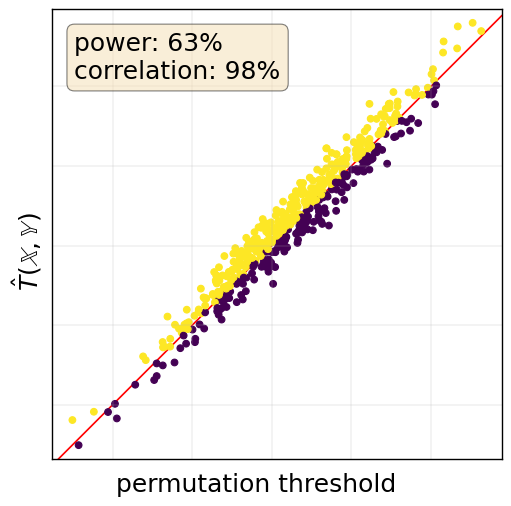

In [ ]:
fig, ax = plt.subplots(squeeze=True, layout='constrained', figsize=(5, 5),)

for i, critic in enumerate(CRITICS):

    T1 = data[critic]['T1']
    thresh = data[critic]['thresh']
    power = (T1 > thresh).mean()
    corr = np.corrcoef(T1, thresh)[0, 1]

    ax.scatter(x=thresh, y=T1, c=T1>thresh)

    # plot y=x
    ax.axline((T1[0], T1[0]), slope=1, color='red', zorder=-1)

    # text box
    info = "\n".join([
        f"power: {power:.0%}",
        f"correlation: {corr:.0%}"
    ])
    bbox_properties = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    # ax.text(0.95, 0.05, info, transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right', bbox=bbox_properties, fontsize=18,)
    ax.text(0.05, 0.95, info, transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', bbox=bbox_properties, fontsize=18,)

    # axis properties
    ax.grid(linewidth=0.2)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.tick_params(left=False, bottom=False)
    ax.set_aspect('equal')
    ax.set_box_aspect(1)

fig.supxlabel(r'permutation threshold', fontsize=18)
fig.supylabel(r'$\hat{T}(\mathbb{X}, \mathbb{Y}\,)$', fontsize=18)

# plt.savefig(f'{critic}-vs-thresh-{DATASET}-1.pdf', bbox_inches='tight')
